In [1]:
print("Colab is ready")

Colab is ready


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive

'Colab Notebooks'		'Google Earth'
 gnr638_corruption_results.csv	 resnet50_finetuning_results.csv
 gnr638_resnet50_mini.pth	 train_data.zip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
station_info = pd.read_csv("/content/All_CONUS_Station_Information_V2.csv")

temp = pd.read_csv("/content/USCRN_AirTemperature_2006_2021.csv")
precip = pd.read_csv("/content/USCRN_Precipitation_2006_2021.csv")
rh = pd.read_csv("/content/USCRN_RelativeHumidity_2006_2021.csv")
soil_moist = pd.read_csv("/content/USCRN_SoilMoisture10cm_2006_2021.csv")
soil_temp = pd.read_csv("/content/USCRN_SoilTemperature_2006_2021.csv")

In [6]:
print(station_info.head())
print(temp.head())

                          StationName  StationID     Lon    Lat
0                  AK_Fairbanks_11_NE      26494 -147.51  64.97
1                       AK_Sitka_1_NE      25379 -135.33  57.06
2                    AK_St._Paul_4_NE      25711 -170.21  57.16
3  AK_Utqiaġvik_formerly_Barrow_4_ENE      27516 -156.61  71.32
4                     AL_Gadsden_19_N      63857  -85.96  34.29
               date  AK_Fairbanks_11_NE  AK_Sitka_1_NE  AK_St._Paul_4_NE  \
0  01-01-2006 00:00              263.05         275.55            270.35   
1  02-01-2006 00:00              259.65         274.85            270.35   
2  03-01-2006 00:00              259.55         274.55            267.75   
3  04-01-2006 00:00              258.25         278.05            265.25   
4  05-01-2006 00:00              256.75         278.05            265.95   

   AK_Utqiaġvik_formerly_Barrow_4_ENE  AL_Gadsden_19_N  AL_Selma_13_WNW  \
0                              255.35           280.45           286.75   
1        

In [7]:
print(temp.info())
print(temp.isnull().sum().head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Columns: 235 entries, date to AK_Aleknagik_1_NNE
dtypes: float64(234), object(1)
memory usage: 10.5+ MB
None
date                                    0
AK_Fairbanks_11_NE                    143
AK_Sitka_1_NE                          39
AK_St._Paul_4_NE                      146
AK_Utqiaġvik_formerly_Barrow_4_ENE    214
dtype: int64


In [8]:
temp_long = temp.melt(id_vars=["date"], var_name="StationName", value_name="temperature")

In [9]:
temp_geo = temp_long.merge(station_info, on="StationName", how="left")

In [10]:
temp_geo["date"] = pd.to_datetime(temp_geo["date"], errors="coerce")

In [11]:
print(temp_geo.head())
print(temp_geo.isnull().sum())

        date         StationName  temperature  StationID     Lon    Lat
0 2006-01-01  AK_Fairbanks_11_NE       263.05      26494 -147.51  64.97
1 2006-02-01  AK_Fairbanks_11_NE       259.65      26494 -147.51  64.97
2 2006-03-01  AK_Fairbanks_11_NE       259.55      26494 -147.51  64.97
3 2006-04-01  AK_Fairbanks_11_NE       258.25      26494 -147.51  64.97
4 2006-05-01  AK_Fairbanks_11_NE       256.75      26494 -147.51  64.97
date           828360
StationName         0
temperature    442276
StationID           0
Lon                 0
Lat                 0
dtype: int64


In [12]:
temp_geo_clean = temp_geo.dropna(subset=["temperature"])

In [13]:
print("Before:", len(temp_geo))
print("After:", len(temp_geo_clean))
print(temp_geo_clean.isnull().sum())

Before: 1367496
After: 925220
date           560715
StationName         0
temperature         0
StationID           0
Lon                 0
Lat                 0
dtype: int64


In [14]:
temp_geo_clean = temp_geo_clean.sort_values(["date", "StationName"])

In [15]:
lat_grid = np.arange(25, 51, 2)
lon_grid = np.arange(-125, -64, 2)

grid_points = [(lat, lon) for lat in lat_grid for lon in lon_grid]

grid_df = pd.DataFrame(grid_points, columns=["Lat", "Lon"])

In [16]:
print("Grid points:", len(grid_df))
grid_df.head()

Grid points: 403


,Lat,Lon
0,25,-125
1,25,-123
2,25,-121
3,25,-119
4,25,-117


In [17]:
stations = temp_geo_clean[["Lat", "Lon"]].values
values = temp_geo_clean["temperature"].values

In [18]:
from scipy.spatial import cKDTree
import numpy as np

def idw_interpolation(stations, values, grid_points, k=8):
    tree = cKDTree(stations)
    dist, idx = tree.query(grid_points, k=k)

    # avoid divide by zero
    dist = np.where(dist == 0, 1e-12, dist)

    weights = 1 / dist
    weights = weights / weights.sum(axis=1, keepdims=True)

    interpolated = np.sum(weights * values[idx], axis=1)
    return interpolated

In [19]:
grid_coords = grid_df[["Lat", "Lon"]].values

grid_df["temperature_idw"] = idw_interpolation(stations, values, grid_coords)

In [20]:
grid_df.head()

,Lat,Lon,temperature_idw
0,25,-125,289.275
1,25,-123,289.275
2,25,-121,291.850
3,25,-119,291.850
4,25,-117,287.450


In [21]:
eval_df = grid_df.copy()

In [22]:
eval_df["era5_temp"] = np.nan

In [26]:
!pip install --upgrade cdsapi

In [27]:
%%writefile ~/.cdsapirc
url: https://cds.climate.copernicus.eu/api
key: 9aadff19-25a1-44cd-80c9-056a2a73da3c

Overwriting /root/.cdsapirc


In [28]:
import cdsapi

c = cdsapi.Client()
print("CDS API fixed and working")

CDS API fixed and working


In [29]:
import cdsapi
import xarray as xr
import numpy as np

In [30]:
c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': '2m_temperature',
        'year': '2020',
        'month': '01',
        'day': [
            '01','02','03','04','05'
        ],
        'time': [
            '00:00','06:00','12:00','18:00'
        ],
        'format': 'netcdf',
        'area': [50, -125, 25, -65]  # North, West, South, East (USA)
    },
    'era5_test.nc'
)

2026-05-01 10:01:24,898 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

ce57fa15751d63c78d2265d7a2da405f.nc:   0%|          | 0.00/793k [00:00<?, ?B/s]

'era5_test.nc'

In [31]:
ds = xr.open_dataset("era5_test.nc")
print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:     (valid_time: 20, latitude: 101, longitude: 241)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 160B 2020-01-01 ... 2020-01-05T18...
  * latitude    (latitude) float64 808B 50.0 49.75 49.5 ... 25.5 25.25 25.0
  * longitude   (longitude) float64 2kB -125.0 -124.8 -124.5 ... -65.25 -65.0
    number      int64 8B ...
    expver      (valid_time) <U4 320B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-01T10:01 GRIB to CDM+CF via cfgrib-0.9.1...


In [33]:
era5_mean = ds["t2m"].mean(dim="valid_time")

In [34]:
era5_df = era5_mean.to_dataframe().reset_index()
era5_df.head()

,latitude,longitude,number,t2m
0,50.0,-125.00,0,279.005035
1,50.0,-124.75,0,278.663513
2,50.0,-124.50,0,277.076813
3,50.0,-124.25,0,275.384918
4,50.0,-124.00,0,273.862061


In [35]:
era5_df = era5_df.rename(columns={
    "latitude": "Lat",
    "longitude": "Lon",
    "t2m": "era5_temp"
})

In [36]:
era5_df["Lat"] = (era5_df["Lat"] // 2) * 2
era5_df["Lon"] = (era5_df["Lon"] // 2) * 2

In [37]:
era5_2deg = era5_df.groupby(["Lat", "Lon"]).mean().reset_index()

In [38]:
final_df = grid_df.merge(era5_2deg, on=["Lat", "Lon"], how="inner")
final_df.head()

,Lat,Lon,temperature_idw,number,era5_temp


In [40]:
lat_grid = np.arange(26, 51, 2)
lon_grid = np.arange(-124, -64, 2)

master_grid = pd.DataFrame(
    [(lat, lon) for lat in lat_grid for lon in lon_grid],
    columns=["Lat", "Lon"]
)

In [41]:
grid_df["Lat"] = (grid_df["Lat"] // 2) * 2
grid_df["Lon"] = (grid_df["Lon"] // 2) * 2

idw_2deg = grid_df.groupby(["Lat", "Lon"]).mean().reset_index()

In [42]:
era5_2deg["Lat"] = (era5_2deg["Lat"] // 2) * 2
era5_2deg["Lon"] = (era5_2deg["Lon"] // 2) * 2

era5_2deg = era5_2deg.groupby(["Lat", "Lon"]).mean().reset_index()

In [43]:
test_merge = idw_2deg.merge(era5_2deg, on=["Lat", "Lon"], how="inner")

print("Matched points:", len(test_merge))
test_merge.head()

Matched points: 403


,Lat,Lon,temperature_idw,number,era5_temp
0,24,-126,289.275,0.0,291.019592
1,24,-124,289.275,0.0,290.847473
2,24,-122,291.850,0.0,290.714783
3,24,-120,291.850,0.0,290.749237
4,24,-118,287.450,0.0,290.836426


In [50]:
from scipy.spatial import cKDTree

# ERA5 coordinates
era_coords = era5_2deg[["Lat", "Lon"]].values
era_values = era5_2deg["era5_temp"].values

# Build KDTree
tree = cKDTree(era_coords)

# Use YOUR grid (IMPORTANT)
grid_coords = grid_df[["Lat", "Lon"]].values

# Find nearest ERA5 point for each grid point
dist, idx = tree.query(grid_coords, k=1)

# Assign ERA5 values to YOUR grid
grid_df["era5_temp"] = era_values[idx]

In [51]:
final_df = grid_df.copy()

print("Final points:", len(final_df))
final_df.head()

Final points: 403


,Lat,Lon,temperature_idw,era5_temp
0,24,-126,289.275,291.019592
1,24,-124,289.275,290.847473
2,24,-122,291.850,290.714783
3,24,-120,291.850,290.749237
4,24,-118,287.450,290.836426


In [52]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(
    final_df["era5_temp"],
    final_df["temperature_idw"]
))

print("RMSE:", rmse)

RMSE: 9.728727685290242


In [53]:
corr = final_df["era5_temp"].corr(final_df["temperature_idw"])
print("Correlation:", corr)

Correlation: 0.50977749773558


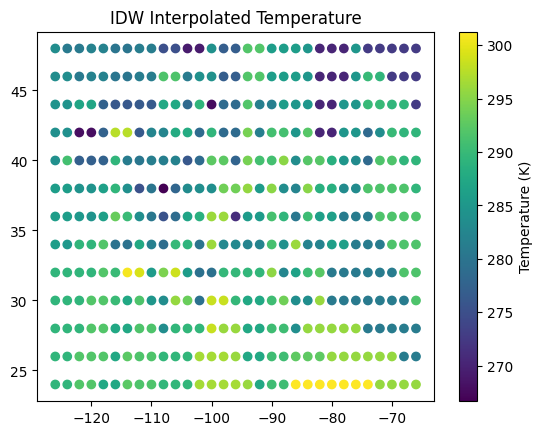

In [54]:
plt.scatter(grid_df["Lon"], grid_df["Lat"], c=grid_df["temperature_idw"])
plt.colorbar(label="Temperature (K)")
plt.title("IDW Interpolated Temperature")
plt.show()

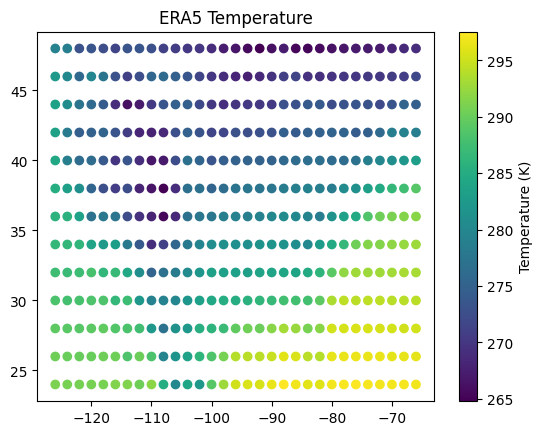

In [55]:
plt.scatter(grid_df["Lon"], grid_df["Lat"], c=grid_df["era5_temp"])
plt.colorbar(label="Temperature (K)")
plt.title("ERA5 Temperature")
plt.show()

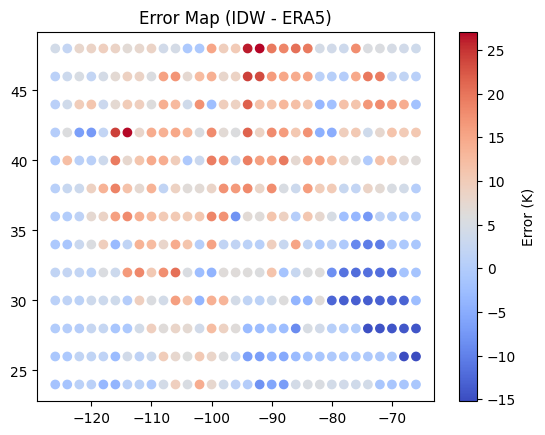

In [56]:
grid_df["error"] = grid_df["temperature_idw"] - grid_df["era5_temp"]

plt.scatter(grid_df["Lon"], grid_df["Lat"], c=grid_df["error"], cmap="coolwarm")
plt.colorbar(label="Error (K)")
plt.title("Error Map (IDW - ERA5)")
plt.show()

In [57]:
print("IDW mean:", final_df["temperature_idw"].mean())
print("ERA5 mean:", final_df["era5_temp"].mean())

print("IDW std:", final_df["temperature_idw"].std())
print("ERA5 std:", final_df["era5_temp"].std())

IDW mean: 286.3124379652606
ERA5 mean: 281.00903
IDW std: 7.129211954131959
ERA5 std: 9.025983810424805


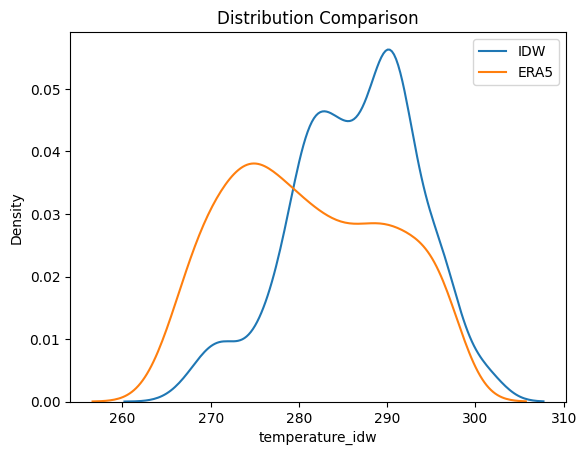

In [58]:
import seaborn as sns

sns.kdeplot(final_df["temperature_idw"], label="IDW")
sns.kdeplot(final_df["era5_temp"], label="ERA5")
plt.legend()
plt.title("Distribution Comparison")
plt.show()

In [59]:
def nearest_interp(stations, values, grid_points):
    tree = cKDTree(stations)
    _, idx = tree.query(grid_points, k=1)
    return values[idx]

grid_df["temp_nn"] = nearest_interp(stations, values, grid_coords)

In [60]:
final_nn = grid_df.dropna(subset=["temp_nn", "era5_temp"])

print("Points used:", len(final_nn))

Points used: 403


In [61]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_nn = np.sqrt(mean_squared_error(
    final_nn["era5_temp"],
    final_nn["temp_nn"]
))

print("NN RMSE:", rmse_nn)

NN RMSE: 10.77032946747778


In [62]:
corr_nn = final_nn["era5_temp"].corr(final_nn["temp_nn"])
print("NN Correlation:", corr_nn)

NN Correlation: 0.5989083576777664


In [63]:
print("IDW RMSE:", rmse)
print("IDW Corr:", corr)

print("\nNN RMSE:", rmse_nn)
print("NN Corr:", corr_nn)

IDW RMSE: 9.728727685290242
IDW Corr: 0.50977749773558

NN RMSE: 10.77032946747778
NN Corr: 0.5989083576777664


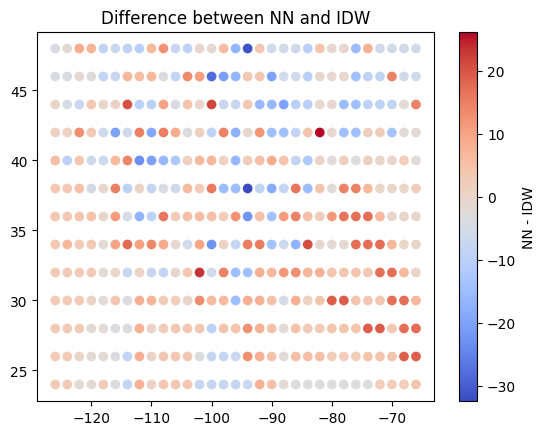

In [64]:
grid_df["diff_nn_idw"] = grid_df["temp_nn"] - grid_df["temperature_idw"]

plt.scatter(grid_df["Lon"], grid_df["Lat"], c=grid_df["diff_nn_idw"], cmap="coolwarm")
plt.colorbar(label="NN - IDW")
plt.title("Difference between NN and IDW")
plt.show()

In [65]:
plt.savefig("idw_map.png", dpi=300, bbox_inches='tight')
plt.savefig("era5_map.png", dpi=300, bbox_inches='tight')
plt.savefig("error_map.png", dpi=300, bbox_inches='tight')
plt.savefig("distribution.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>